## Import Libraries

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

try:
    _ = SentimentIntensityAnalyzer()
except:
    import contextlib
    import os
    with open(os.devnull, 'w') as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            nltk.download('vader_lexicon')

## Load Dataset

In [22]:
import pandas as pd

df = pd.read_csv("filtered_student_chatgpt_reddit.csv", dtype=str)
df = df.drop_duplicates(subset=['body'])
df = df.dropna(subset=['subreddit', 'body'])

keywords = [
    'chatgpt',
    'ai',
    'school',
    'college',
    'student',
    'homework',
    'study',
    'studying',
    'exam',
    'assignment',
    'class',
    'teacher',
    'professor',
    'education',
    'university']

pattern = '|'.join(keywords)

df = df[
    df['body'].str.contains(pattern)]

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df[['subreddit', 'body', 'score']].head()

,subreddit,body,score
0,gaming,it's pretty well known and it was a paid produ...,3.0
2,news,the character 令 does bear a meaning similar to...,8.0
3,SquaredCircle,wrong. young footballers to this day help arou...,25.0
4,news,"thanks for the interesting response, this shed...",0.0
5,AskReddit,my father went to a private upper class law sc...,1.0


## Sentiment Analysis (VADER)

In [23]:
sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['body'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])

def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)
df[['body', 'sentiment_score', 'sentiment']].head()

,body,sentiment_score,sentiment
0,it's pretty well known and it was a paid produ...,0.8074,Positive
2,the character 令 does bear a meaning similar to...,0.2510,Positive
3,wrong. young footballers to this day help arou...,-0.8059,Negative
4,"thanks for the interesting response, this shed...",0.6778,Positive
5,my father went to a private upper class law sc...,0.7886,Positive


## Sentiment Distributions

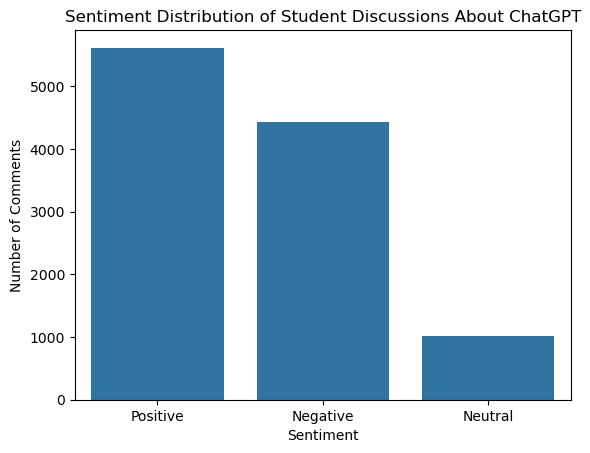

In [24]:
sns.countplot(data=df, x='sentiment')
plt.title('Sentiment Distribution of Student Discussions About ChatGPT')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

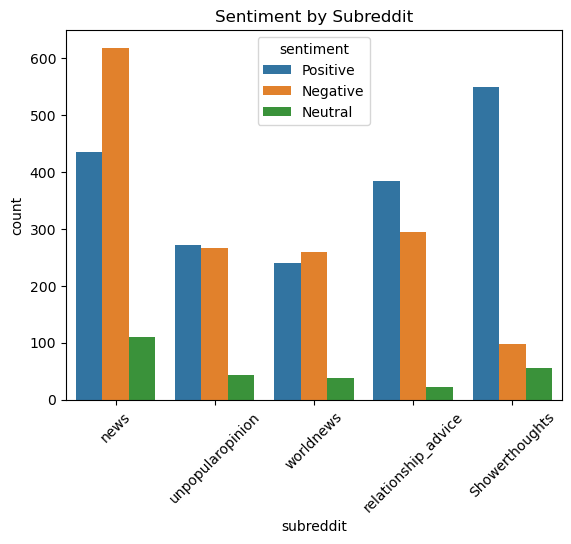

In [25]:
top_subs = df['subreddit'].value_counts().head(5).index

filtered_df = df[df['subreddit'].isin(top_subs)]

sns.countplot(data=filtered_df, x='subreddit', hue='sentiment')
plt.xticks(rotation=45)
plt.title('Sentiment by Subreddit')
plt.show()

## Positive and Negative Comments

In [26]:
print("Top Positive Comments:")
display(df[df['sentiment'] == 'Positive'].sort_values(by='sentiment_score', ascending=False).head(5))

print("Top Negative Comments:")
display(df[df['sentiment'] == 'Negative'].sort_values(by='sentiment_score').head(5))

Top Positive Comments:


,subreddit,body,controversiality,score,comment_id,comment_parent_id,comment_body,Topic,Tag,sentiment_score,sentiment
11486,relationship_advice,"well, in my experience, i've friendzoned a lot...",0.0,1.0,NaN,NaN,NaN,NaN,NaN,0.9995,Positive
10905,movies,&gt; all but nat and thors mom.\n\nyou mean th...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.9993,Positive
11146,relationship_advice,we moved in togheter as soons as i got my firs...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,0.9993,Positive
761,leagueoflegends,"long post incoming, i apologize. i also typed ...",0.0,7.0,NaN,NaN,NaN,NaN,NaN,0.9992,Positive
2673,worldnews,i got really interested in it basically as soo...,0.0,3.0,NaN,NaN,NaN,NaN,NaN,0.9991,Positive


Top Negative Comments:


,subreddit,body,controversiality,score,comment_id,comment_parent_id,comment_body,Topic,Tag,sentiment_score,sentiment
1175,unpopularopinion,do you know why? because most people hearing ...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,-0.9998,Negative
2698,worldnews,wrong. australia's crime rate continued to dec...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,-0.9996,Negative
9054,ChapoTrapHouse,"my boy, my oldest child, was so good when he w...",0.0,2.0,NaN,NaN,NaN,NaN,NaN,-0.9995,Negative
9794,pics,this is a bit of a cringy response and i'm loo...,0.0,2.0,NaN,NaN,NaN,NaN,NaN,-0.9994,Negative
6054,news,i was simply stating a fact for you. explosive...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,-0.9994,Negative


## Subreddit Sentiments

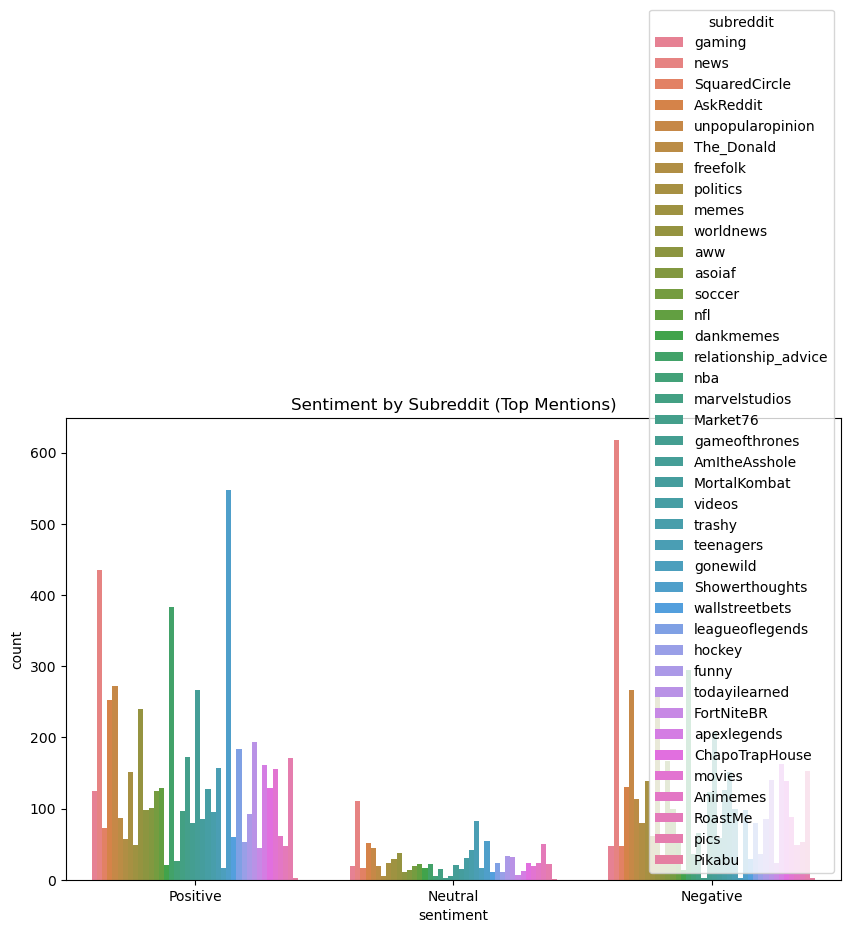

In [27]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='sentiment', hue='subreddit', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment by Subreddit (Top Mentions)')
plt.xticks(rotation=0)
plt.show()

## Final Data Essay

For this project, I chose to explore how students discuss ChatGPT and artificial intelligence in academic spaces. AI tools like ChatGPT are becoming increasingly common in schools and universities, but students have very mixed opinions about them. Some students see AI as a helpful study tool, while others believe it hurts learning or creates ethical concerns related to cheating and overreliance on technology. Because many of these discussions happen online, especially on Reddit, I wanted to analyze how students emotionally respond to AI in education and how those conversations can be transformed into data.

The process of building the dataset happened in multiple stages. First, I manually created the the first dataset used for this project. I gathered around seventy Reddit entries focused on student discussions about ChatGPT, assignments, studying, and AI use in school. During this stage, I manually reviewed posts and comments to decide whether they were relevant to education. This process was time consuming, but it helped me better understand the kinds of conversations students were having about AI in academic settings.

After creating the initial dataset, had to scale my data. I searched for a larger existing dataset related to student AI usage. The dataset I found mainly focused on how students used AI tools rather than how they emotionally felt about them. Since my research question focused more on student reactions and opinions, I needed to reorganize and clean the dataset myself. I realized that many posts were unrelated to academics or did not actually discuss opinions about AI. I also removed rows containing missing values, deleted posts, duplicate entries, and comments that were too short to provide meaningful insights. During the cleaning process, I discovered that some discussions in the dataset were connected to unrelated subreddits and topics despite being included in the original collection. Because of this, I filtered the data further using education and AI related keywords in order to focus the final dataset more specifically on student discussions about academics and ChatGPT. 

Once the dataset was cleaned, I used Python in Jupyter Notebook to analyze the data computationally. I worked with libraries such as Pandas and Matplotlib to organize and visualize the information. I also used the VADER sentiment analysis tool from NLTK to examine the emotional tone of Reddit posts and comments. This became one of the most important parts of the project because the original dataset only measured AI usage, not sentiment. By applying VADER, I was able to transform the dataset into one that could classify posts as positive, neutral, or negative. The computational analysis helped reveal patterns that would have been difficult to identify manually. Some students described ChatGPT as helpful for studying, brainstorming ideas, or reducing stress during assignments. Others expressed concerns about cheating, dependency, inaccurate information, or weaker critical thinking skills. Many students also seemed conflicted, recognizing both the benefits and risks of AI in education at the same time. Using sentiment analysis simplified these discussions into categories that could be visualized and compared across the dataset.

The visualizations also revealed several important patterns within the dataset. The overall sentiment distribution graph showed that positive and negative opinions about ChatGPT were both very common, while neutral discussions appeared much less frequently. This suggests that students often have strong emotional reactions to AI in education rather than viewing it as a completely neutral technology. The larger number of positive comments reflected how many students see ChatGPT as useful for studying, brainstorming, or managing academic stress. At the same time, the similarly large number of negative comments demonstrated that concerns about cheating, dependency, misinformation, and reduced critical thinking are also widespread. The visualizations showed that discussions about AI in academics are highly polarized, with students often expressing either strong support or strong criticism. This is also shown through the sentiment scores on the top positive and negative comments. The scores for the positive comments are very close to 1, while the scores on the negative comments are very close to -1. These extreme values further demonstrate how polarized many of the discussions were, since the sentiment analysis model interpreted a large number of comments as expressing very strong approval or very strong criticism rather than moderate or neutral opinions about AI in education.

The subreddit comparison graphs also highlighted how online communities shape discussions differently. Some subreddits contained noticeably more positive discussions, while others showed more negative reactions toward AI tools. This demonstrated that sentiment surrounding ChatGPT is influenced by the culture and expectations of specific online communities rather than existing as one universal opinion. The subreddit analysis also reinforced the importance of filtering and cleaning the dataset carefully, since some communities included discussions unrelated to academics despite appearing in the original dataset.

This project also changed the way I thought about the relationship between culture and data. Reddit discussions are emotional, informal, and personal, but once they are collected into a dataset they become structured pieces of information that can be sorted and analyzed computationally. Turning online conversations into data made it easier to identify larger patterns, but it also removed some of the context behind individual posts. For example, humor, sarcasm, and frustration are not always interpreted correctly through sentiment analysis tools. The project also raised ethical considerations. Even though Reddit posts are public, users may not expect their comments to become part of a dataset or research project. In addition, Reddit users do not represent all students, so the dataset cannot fully capture every perspective about AI in education.

Overall, this project changed how I think about datasets and computational research. I learned that datasets are shaped by human decisions during collection, filtering, and analysis. I also learned that computation can help analyze culture at a larger scale, but it cannot completely capture the complexity of human opinions and communication. This project connects to broader scholarship about AI in education and digital humanities, where researchers examine how computational tools shape learning, communication, and online culture. My dataset reflects many of the same tensions discussed in these studies, especially concerns about ethics, dependency, and the changing role of technology in education.
